# Figure 2 - Single cell panels
Mathieu Bourdenx - UCL/UKDRI - 2026

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import gseapy as gp
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

from scipy.stats import pearsonr, false_discovery_control
from tqdm.notebook import tqdm
import PyComplexHeatmap as pch
from adjustText import adjust_text

# Housekeeping

In [2]:
raw_data_path = '../data/raw_data'
processed_data_path = '../data/processed_data'
results_path = '../results'

figure_path = '../figures/figure2'
os.makedirs(figure_path, exist_ok=True)

In [32]:
# Group colors
group_colors = {'pos': '#FEC200', 
         'neg': '#0C6F9F','positive': '#FEC200', 
         'negative': '#0C6F9F'}

In [4]:
# FDR threshold
fdr_thresh = 0.05

# Load data

In [5]:
sc_ad = sc.read_h5ad(os.path.join(processed_data_path, 'sc_processed.h5ad'))

# Tau levels and AT8 positivity

In [6]:
sc_ad.obs['MAPT'] = list(sc_ad[:, 'MAPT'].X.flatten())

In [7]:
sorted_tau = sc_ad.obs.copy()
sorted_tau = sorted_tau.sort_values(by='MAPT', ascending=True)
sorted_tau.reset_index(drop=True, inplace=True)

In [10]:
color_map = [group_colors['pos'] if i == 'positive' else group_colors['neg'] for i in sorted_tau['TauStatus']]

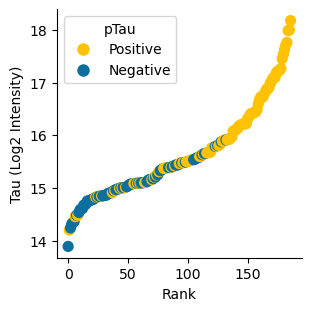

In [12]:
plt.figure(figsize=(3,3), constrained_layout=True)
plt.scatter(sorted_tau.index, sorted_tau['MAPT'], c=color_map, s=50, alpha=1)
plt.xlabel('Rank')
plt.ylabel('Tau (Log2 Intensity)')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Positive',
           markerfacecolor=group_colors['pos'], markersize=10, alpha=1),
    Line2D([0], [0], marker='o', color='w', label='Negative',
           markerfacecolor=group_colors['neg'], markersize=10, alpha=1)
]
plt.legend(handles=legend_elements, title='pTau')

sns.despine()
plt.savefig(os.path.join(figure_path, 'Fig2a_tau_sorted.png'), dpi=300)
plt.show()


# Protein correlation with tau levels

In [13]:
sc_ad.var['corr_stat'] = None
sc_ad.var['corr_pval'] = None

pval_list = []

for i in tqdm(sc_ad.var.index):

    stat, pval = pearsonr(sc_ad[:, i].X.flatten(), sc_ad[:, 'MAPT'].X.ravel())
    sc_ad.var.loc[i, 'corr_stat'] = stat
    sc_ad.var.loc[i, 'corr_pval'] = pval
    pval_list.append(pval)

sc_ad.var['corr_adj.pval'] = false_discovery_control(pval_list, method='bh')

  0%|          | 0/2131 [00:00<?, ?it/s]

In [14]:
# Export results for paper
sc_ad.var[['UniprotID', 'UniprotName', 'GeneName', 'corr_stat', 'corr_pval', 'corr_adj.pval']].to_csv(os.path.join(results_path, 'SuppTable3_sc_correlation_tau.csv'))


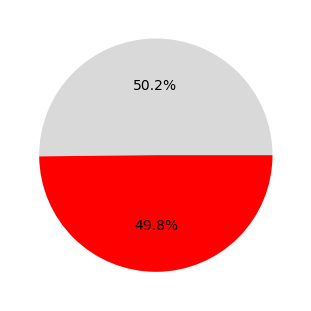

In [15]:
# Number of hits
n_hits = (sc_ad.var['corr_adj.pval'] < fdr_thresh).sum()

# Plot pie chart
plt.figure(figsize=(3,3), constrained_layout=True)
plt.pie([sc_ad.shape[1]-n_hits, n_hits], autopct='%1.1f%%', colors=['.85', 'red'])
plt.show()

/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/matplotlib/text.py:905: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/matplotlib/text.py:762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) 

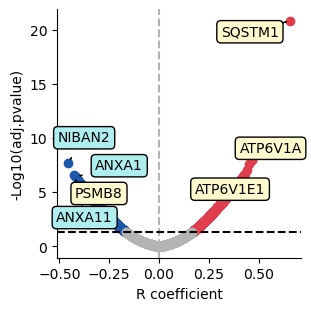

In [16]:
# Volcano plot

plt.figure(figsize=(3,3), constrained_layout=True)

plt.axvline(x=0, linestyle='dashed', color='.7')

plt.axhline(y=-np.log10(fdr_thresh), linestyle='dashed', color='k')

plt.scatter(sc_ad.var[(sc_ad.var['corr_adj.pval'] < fdr_thresh) & (sc_ad.var['corr_stat'] > 0)]['corr_stat'], 
            -np.log10(sc_ad.var[(sc_ad.var['corr_adj.pval'] < fdr_thresh) & (sc_ad.var['corr_stat'] > 0)]['corr_adj.pval']), color='#DE3E4E')

plt.scatter(sc_ad.var[(sc_ad.var['corr_adj.pval'] < fdr_thresh) & (sc_ad.var['corr_stat'] < 0)]['corr_stat'], 
            -np.log10(sc_ad.var[(sc_ad.var['corr_adj.pval'] < fdr_thresh) & (sc_ad.var['corr_stat'] < 0)]['corr_adj.pval']), color='#1D57A9')

plt.scatter(sc_ad.var[sc_ad.var['corr_adj.pval'] > fdr_thresh]['corr_stat'], -np.log10(sc_ad.var[sc_ad.var['corr_adj.pval'] > fdr_thresh]['corr_adj.pval']), color='.7')

hits = ['SQSTM1','PSMB8', 'ATP6V1A', 'ATP6V1E1', 'ANXA11', 'NIBAN2', 'ANXA1']
colors = ['lemonchiffon', 'lemonchiffon', 'lemonchiffon', 'lemonchiffon', 'paleturquoise', 'paleturquoise', 'paleturquoise']

texts = []
for i,j in zip(hits, colors):
    props = dict(boxstyle='round', facecolor=j, alpha=1)
    texts.append(plt.text(sc_ad.var[sc_ad.var['GeneName'] == i]['corr_stat'], -np.log10(sc_ad.var[sc_ad.var['GeneName'] == i]['corr_adj.pval']), s=i, 
                      ha='center', va='center', bbox=props))

adjust_text(texts, expand=(1.8, 1.8), # expand text bounding boxes by 1.2 fold in x direction and 2 fold in y direction
             arrowprops=dict(arrowstyle='->', color='k') # ensure the labeling is clear by adding arrows
             );

sns.despine()
plt.ylabel('-Log10(adj.pvalue)')
plt.xlabel(r'R coefficient')

plt.savefig(os.path.join(figure_path, 'Fig2g_volcano_plot.png'), dpi=300)

plt.show()

# Heatmap

In [17]:
# Rank data on tau levels
tau_idx = sc_ad.obs.index[np.argsort(sc_ad[:, 'MAPT'].X.flatten())]

In [18]:
data = sc_ad[tau_idx, sc_ad.var['corr_adj.pval'] < fdr_thresh].X.T

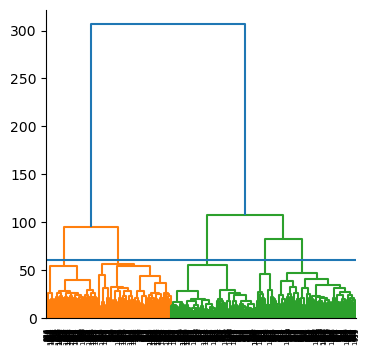

In [19]:
data_z = (data - data.mean(axis=1, keepdims=True)) / data.std(axis=1, keepdims=True)

# Correlation distance
dist = pdist(data_z, metric='euclidean')

# Hierarchical clustering
Z = linkage(dist, method='ward')

# Plot dendrogram
dendrogram(Z)
plt.axhline(y=60)
plt.show()

In [20]:
clusters = fcluster(Z, t=6, criterion='maxclust') 

In [21]:
clusters_var = sc_ad.var[sc_ad.var['corr_adj.pval'] < fdr_thresh]
clusters_var['cluster'] = clusters
clusters_var.reset_index(inplace=True, drop=True)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_28493/3762057121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clusters_var['cluster'] = clusters


In [23]:
sorted_obs = sc_ad.obs.copy().sort_values(by='MAPT', ascending=True)
sorted_obs.index = tau_idx


In [25]:
case_id = {
    '35/18': 1,
    '68/19': 2,
    '5/12': 3,
    '78/15': 4,
    '75/13': 5,
    '54/16': 6,
    '8/11': 7,
    '14/13': 8,
    '3/16': 9,
    '93/17': 10
}

# Map patient ID to case ID
sc_ad.obs['case_id'] = sc_ad.obs['PatientID'].map(case_id)


In [26]:
# Log2 ptau intensities
sorted_obs['Log2pTau_217'] = np.log2(sorted_obs['pTau_217'] + 1)
sorted_obs['Log2pTau_231'] = np.log2(sorted_obs['pTau_231'] + 1)
sorted_obs['Log2pTau_202'] = np.log2(sorted_obs['pTau_202'] + 1)
sorted_obs['Log2pTau_404'] = np.log2(sorted_obs['pTau_404'] + 1)

In [31]:
sc_ad.obs.head()

,Sample_name,Plate,PatientTau,PatientID,Mode,TauStatus,SampleID,mergingID,PMI hours,Age at death,Run,intensity_ub,sample_name,pTau_202,pTau_217,pTau_231,pTau_404,pTau,MAPT,case_id
0,S2-A1,3,14/13+,14/13,single,positive,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,14/13,35.04,69.0,Bluto_20250228_FCo_AlzheimerCohort_MaFo_B3_S2-...,15.740272,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,0.0,0.0,0.0,0.0,False,15.159245,8
1,S2-A3,3,14/13+,14/13,single,positive,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,14/13,35.04,69.0,Bluto_20250228_FCo_AlzheimerCohort_MaFo_B5_S2-...,16.192575,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,0.0,0.0,0.0,0.0,False,15.678370,8
2,S2-A4,3,14/13+,14/13,single,positive,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,14/13,35.04,69.0,Bluto_20250228_FCo_AlzheimerCohort_MaFo_B6_S2-...,14.085995,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,0.0,0.0,0.0,0.0,False,14.456226,8
3,S2-A5,3,14/13+,14/13,single,positive,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,14/13,35.04,69.0,Bluto_20250228_FCo_AlzheimerCohort_MaFo_B7_S2-...,14.741933,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,0.0,0.0,0.0,0.0,False,16.133877,8
4,S2-A7,3,14/13+,14/13,single,positive,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,14/13,35.04,69.0,Bluto_20250228_FCo_AlzheimerCohort_MaFo_B9_S2-...,14.411484,D:\Proteomics\Fabian\Martha\samples400\Bluto_2...,0.0,0.0,0.0,0.0,False,15.380803,8


In [33]:
col_annot = pch.HeatmapAnnotation(
    PatientID = pch.anno_simple(sc_ad.obs.loc[tau_idx,'case_id'], cmap='tab10'),
    TauStatus = pch.anno_simple(sc_ad.obs.loc[tau_idx,'TauStatus'], colors=group_colors),
    TauLevels = pch.anno_simple(sorted_obs['MAPT'], cmap='plasma'),
    pTauMS = pch.anno_simple(sorted_obs['pTau'].astype(int), cmap='gray_r'),
    Ser201 = pch.anno_simple(sorted_obs['Log2pTau_202'], cmap='Reds'),
    Ser404 = pch.anno_simple(sorted_obs['Log2pTau_404'], cmap='Reds'),
    Thr217 = pch.anno_simple(sorted_obs['Log2pTau_217'], cmap='Reds'),
    Thr231 = pch.anno_simple(sorted_obs['Log2pTau_231'], cmap='Reds'),
    hgap = 1
)

In [34]:
row_annot = pch.HeatmapAnnotation(
    Cluster = pch.anno_simple(clusters_var['cluster'], cmap='tab20', legend=True,height=5), 
    axis=0
)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/

Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 23.6375 mm
Incresing ncol
Incresing ncol
More than 3 cols is not supported
Legend too long, generating a new column..


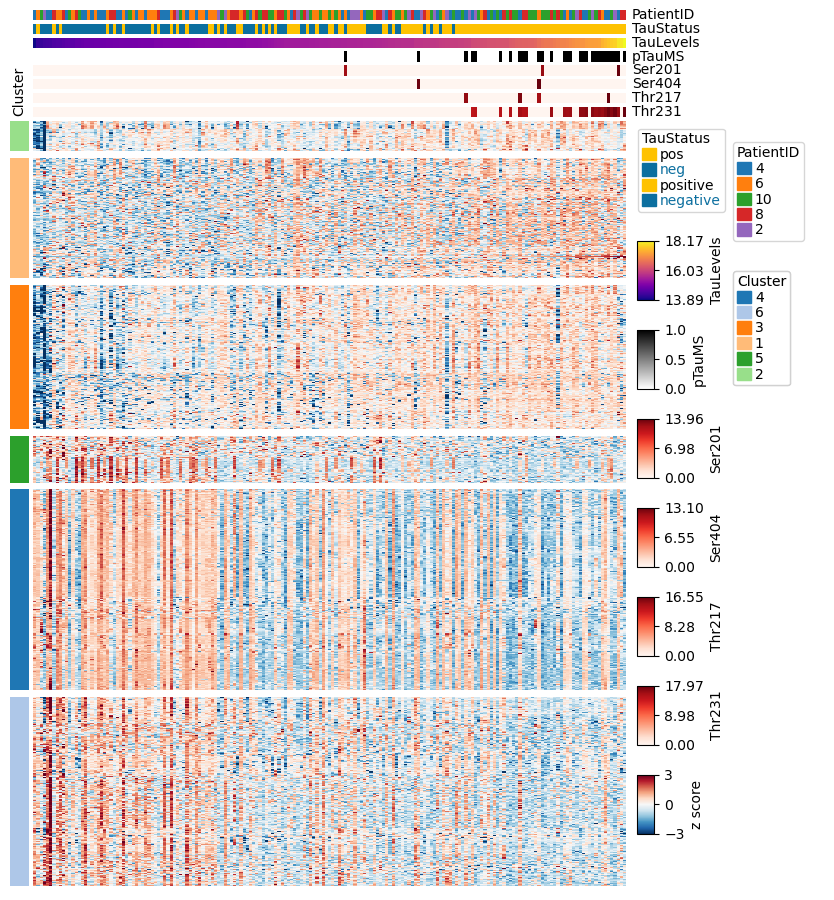

In [35]:
plt.figure(figsize=(8,10))
pch.ClusterMapPlotter(data=pd.DataFrame(sc_ad[tau_idx, sc_ad.var['corr_adj.pval'] < fdr_thresh].X.T, columns=tau_idx), 
                      z_score=0, cmap='RdBu_r', center=0, vmin=-3, vmax=3, col_cluster=False, label='z score', 
                      top_annotation=col_annot, row_cluster_method='ward', row_cluster_metric='euclidean', left_annotation=row_annot, 
                      row_split=clusters_var['cluster'], row_split_gap=1.5)

plt.savefig(os.path.join(figure_path, 'Figb2i_heatmap_tau_corr_patientID.png'), dpi=300, bbox_inches='tight')

# GO analysis of the clusters

In [37]:
for i in clusters_var['cluster'].unique():
    enr_cluster = gp.enrichr(
    gene_list=clusters_var[clusters_var['cluster'] == i]['GeneName'],
    gene_sets=['GO_Biological_Process_2025'],  # choose your DB
    organism='human',
    outdir=None)

    enr_cluster.results.sort_values('Adjusted P-value').to_csv(os.path.join(results_path, f'SC_cluster{i}.csv'))

    ax = gp.dotplot(enr_cluster.res2d, figsize=(3,5), size=5, x="Adjusted P-value", show_ring=True, ofname=os.path.join(figure_path, f'Fig2_SC_enrichment_cluster{i}.png'))

# Heatmap for cell death pathways

In [38]:
pathway_proteins = {
    'Apoptosis': [
        'BAX', 'BAK1', 'BCL2', 'BCL2L1', 'BCL2L11', 'BID', 'BAD', 'PUMA', 'NOXA',
        'CASP3', 'CASP7', 'CASP8', 'CASP9', 'CASP6', 
        'CYCS', 'APAF1', 'DIABLO', 'HTRA2', 
        'XIAP', 'BIRC2', 'BIRC3', 'BIRC5',
        'TP53', 'FAS', 'FASLG', 'FADD', 'TNFRSF1A', 'TRADD', 'RIPK1'
    ],
    
    'Ferroptosis': [
        'GPX4', 'ACSL4', 'LPCAT3', 'ALOX5', 'ALOX12', 'ALOX15',
        'SLC7A11', 'SLC3A2', 'TFRC', 'FTH1', 'FTL', 'NCOA4',
        'FSP1', 'AIFM2', 'NFS1', 'NFE2L2', 'KEAP1',
        'PTGS2', 'HMOX1', 'HSPB1', 'GLS2'
    ],
    
    'Senescence': [
        'CDKN1A', 'CDKN2A', 'CDKN1B', 'CDKN2B', 'CDKN2C', 'CDKN2D',
        'TP53', 'RB1', 'IL6', 'IL8', 'IL1A', 'IL1B',
        'MMP1', 'MMP3', 'MMP9', 'MMP13',
        'CXCL1', 'CXCL2', 'CCL2', 'CCL20',
        'IGFBP3', 'IGFBP5', 'IGFBP7', 'PAI1', 'SERPINE1',
        'GLB1', 'LMNB1', 'HMGB1'
    ],
    
    'Necroptosis': [
        'RIPK1', 'RIPK3', 'MLKL', 'FADD', 'CASP8',
        'TNFRSF1A', 'FAS', 'TRADD', 'TRAF2', 'BIRC2', 'BIRC3',
        'ZBP1', 'TRIF', 'TICAM1', 'TLR3', 'TLR4',
        'PGAM5', 'CYLD', 'LUBAC'
    ],
    
    'Pyroptosis': [
        'GSDMD', 'GSDME', 'GSDMA', 'GSDMB', 'GSDMC',
        'CASP1', 'CASP4', 'CASP5', 'CASP11',
        'NLRP1', 'NLRP3', 'NLRC4', 'AIM2', 'PYCARD',
        'IL1B', 'IL18', 'HMGB1',
        'LDH', 'LDHA', 'LDHB'
    ]
}

In [40]:
selected_celldeath = []

for p in pathway_proteins.keys():
    selected_celldeath.extend(pathway_proteins[p])

selected_celldeath = list(set(selected_celldeath))

selected_celldeath = [i for i in selected_celldeath if i in sc_ad.var['GeneName']]

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 7.5 mm


/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


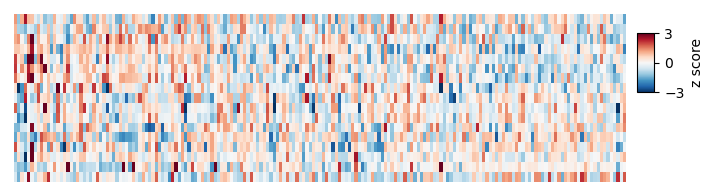

In [45]:
plt.figure(figsize=(8,2))
pch.ClusterMapPlotter(data=pd.DataFrame(sc_ad[tau_idx, selected_celldeath].X.T, index=selected_celldeath, columns=tau_idx), 
                      z_score=0, cmap='RdBu_r', center=0, vmin=-3, vmax=3, col_cluster=False, label='z score', show_rownames=False)

plt.savefig(os.path.join(figure_path, 'Fig2j_heatmap_celldeath.png'), dpi=300, bbox_inches='tight')